In [10]:
from langgraph.graph import START, END, StateGraph
from typing import TypedDict

In [11]:
class BatsmanInput(TypedDict):
    runs: int
    balls: int
    strike_rate: float
    sixes: int
    four: int
    total_boundaries: int
    total_run_by_singles: int

In [12]:
def calculate_strike_rate(state: BatsmanInput) -> dict:
    strike_rate = (state['runs'] / state['balls']) * 100 if state['balls'] > 0 else 0
    return {'strike_rate': strike_rate}


In [13]:
def calculate_boundaries(state: BatsmanInput) -> dict:
    total_boundaries = state['sixes'] + state['four']
    return {'total_boundaries': total_boundaries}

In [14]:
def calculate_singles(state: BatsmanInput) -> dict:
    total_runs_by_boundaries = (state['sixes'] * 6) + (state['four'] * 4)
    total_run_by_singles = state['runs'] - total_runs_by_boundaries
    return {'total_run_by_singles': total_run_by_singles}

In [15]:
graph = StateGraph(BatsmanInput)

graph.add_node('calculate_strike_rate', calculate_strike_rate)
graph.add_node('calculate_boundaries', calculate_boundaries)
graph.add_node('calculate_singles', calculate_singles)

graph.add_edge(START, 'calculate_strike_rate')
graph.add_edge(START, 'calculate_boundaries')
graph.add_edge(START, 'calculate_singles')
graph.add_edge('calculate_strike_rate', END)
graph.add_edge('calculate_boundaries', END)
graph.add_edge('calculate_singles', END)

In [16]:
workflow = graph.compile()

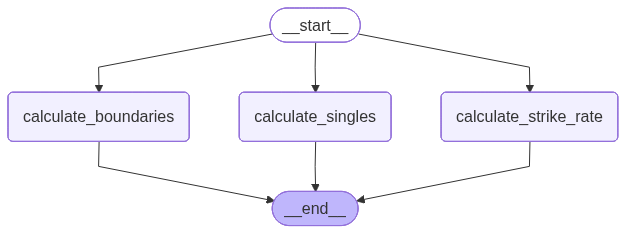

In [17]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [18]:
initial_state = {
    'runs': 120,
    'balls': 60,
    'sixes': 6,
    'four': 10
}

final_state = workflow.invoke(initial_state)
print(final_state)

{'runs': 120, 'balls': 60, 'strike_rate': 200.0, 'sixes': 6, 'four': 10, 'total_boundaries': 16, 'total_run_by_singles': 44}
